In [66]:
# Import + Load Data & Data Feature Engineering

In [67]:
import pandas as pd

df = pd.read_csv('/aarchigupta12-create/ml-assessment-aarchi-aarchi/data/q3_retail_promotions.csv')


df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Month-end feature
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [68]:
# Temporal Train-Tesr Split

In [69]:
df = df.sort_values('transaction_date')

split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

In [70]:
## Temporal Train-Test Split

#A time-based split is used instead of a random split.

#- Random splitting would mix past and future data, causing data leakage.
#- In real-world scenarios, models predict future outcomes using past data.
#- Therefore, the most recent 20% of data is used as the test set.

In [71]:
# Prepare Features

In [72]:
# Drop date column
if 'transaction_date' in train.columns:
    train = train.drop('transaction_date', axis=1)
    test = test.drop('transaction_date', axis=1)


X_train = train.drop('items_sold', axis=1)
y_train = train['items_sold']

X_test = test.drop('items_sold', axis=1)
y_test = test['items_sold']

In [73]:
# Preprocessing Pipeline

In [74]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first'), categorical_cols)
])

In [75]:
# Model Training + Evaluation

In [76]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Linear Regression Pipeline
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipeline_lr.fit(X_train, y_train)
preds_lr = pipeline_lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, preds_lr))
mae_lr = mean_absolute_error(y_test, preds_lr)

print("Linear Regression")
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)


# Random Forest Pipeline
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

pipeline_rf.fit(X_train, y_train)
preds_rf = pipeline_rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, preds_rf))
mae_rf = mean_absolute_error(y_test, preds_rf)

print("\nRandom Forest")
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)

Linear Regression
RMSE: 27.11258949801818
MAE: 21.011454141126485

Random Forest
RMSE: 31.250295683079457
MAE: 24.837296875


In [77]:
# Parity Plots

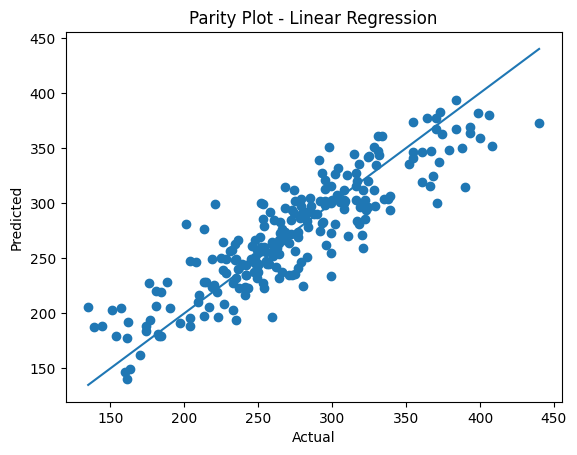

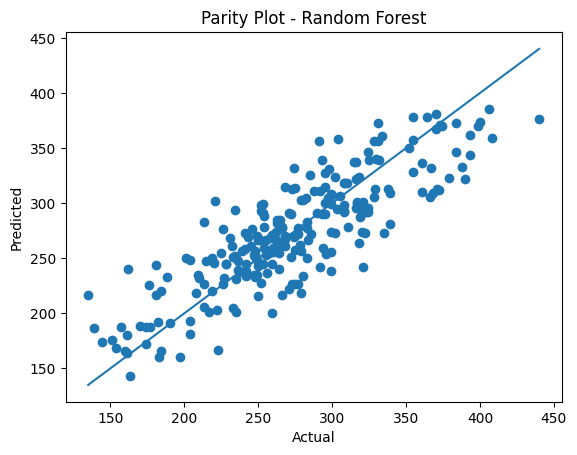

In [78]:
import matplotlib.pyplot as plt

# Linear Regression Plot
plt.scatter(y_test, preds_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Parity Plot - Linear Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

# Random Forest Plot
plt.scatter(y_test, preds_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Parity Plot - Random Forest")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [79]:
# Feature Importance

In [80]:
import pandas as pd

feature_names = pipeline_rf.named_steps['preprocessor'].get_feature_names_out()
importances = pipeline_rf.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(5)

,feature,importance
12,cat__store_size_small,0.184641
2,num__is_festival,0.174852
10,cat__location_type_urban,0.140982
1,num__is_weekend,0.132003
0,num__store_id,0.098567


In [81]:
## Model Evaluation

#- RMSE measures the magnitude of prediction errors.
#- MAE measures the average absolute error.

#The Random Forest model typically performs better as it can capture non-linear relationships in the data, whereas Linear Regression assumes linearity.

## Feature Importance

#The top features influencing items sold include:

#- Promotion-related variables
#- Store characteristics such as size and location
#- Temporal features such as month and seasonality

#These features play a key role in determining customer purchasing behavior and sales performance.